# Chess Cheat Detection — Analysis & Modeling

This notebook loads the dataset generated by `generate_games.py` (11200 Stockfish self-play games across a grid of 7 skill levels × 5 cheat percentages) and trains a classifier to distinguish honest games from games with engine-assisted moves.

**Goal**: given per-game features extracted from the suspect player's moves, predict `is_cheat ∈ {0, 1}`.

**Honest framing of limitations**: the classifier learns to discriminate weak-engine play from weak-engine-with-strong-injections play. It does *not* transfer to human cheating detection, because weak engines and humans have different blunder distributions. This is discussed at the end.

## 1. Setup

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, accuracy_score, f1_score
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

## 2. Load and inspect the dataset

In [37]:
df = pd.read_csv("data/games.csv")
print(f"Games: {len(df)}")
print(f"Class balance: honest={sum(df.is_cheat==0)}, cheat={sum(df.is_cheat==1)}")
df.head()

Games: 11200
Class balance: honest=5600, cheat=5600


,game_id,skill_level,estimated_rating,rating_bucket,cheat_pct,is_cheat,suspect_color,n_moves,result,acpl,acpl_opening,acpl_middlegame,acpl_endgame,top1_match_rate,top3_match_rate,cp_loss_std,cp_loss_median,only_move_match_rate,blunder_rate,mistake_rate
0,8,0,1320,1250-1400,0,0,white,30,0-1,175.700000,37.2,244.950000,0.000000,0.166667,0.233333,249.803142,101.5,0.25,0.233333,0.500000
1,5,0,1320,1250-1400,0,0,white,34,1-0,47.558824,30.4,57.086957,0.000000,0.323529,0.617647,81.075561,9.5,1.00,0.029412,0.176471
2,11,0,1320,1250-1400,0,0,black,32,1-0,105.875000,26.8,141.818182,0.000000,0.281250,0.687500,199.078149,22.5,0.20,0.156250,0.250000
3,2,0,1320,1250-1400,0,0,white,62,1-0,61.564516,21.8,52.628571,103.352941,0.258065,0.580645,133.460109,34.0,0.00,0.048387,0.129032
4,9,0,1320,1250-1400,0,0,white,25,1/2-1/2,45.680000,15.2,66.000000,0.000000,0.520000,0.800000,89.375039,3.0,0.75,0.120000,0.160000


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
game_id,11200.0,5599.500000,3233.305842,0.000000,2799.750000,5599.500000,8399.250000,11199.000000
skill_level,11200.0,9.000000,6.000268,0.000000,3.000000,9.000000,15.000000,18.000000
estimated_rating,11200.0,1902.857143,395.770632,1320.000000,1500.000000,1900.000000,2300.000000,2500.000000
cheat_pct,11200.0,23.125000,33.443374,0.000000,0.000000,5.000000,31.250000,100.000000
is_cheat,11200.0,0.500000,0.500022,0.000000,0.000000,0.500000,1.000000,1.000000
n_moves,11200.0,61.145625,23.045159,6.000000,43.000000,59.000000,79.000000,100.000000
acpl,11200.0,38.668912,35.904611,0.466667,11.362727,27.135632,55.187780,290.043478
acpl_opening,11200.0,16.230379,15.412297,0.000000,6.600000,12.100000,20.400000,335.200000
acpl_middlegame,11200.0,33.984215,38.852756,0.000000,11.608333,21.747340,42.269231,1000.000000
acpl_endgame,11200.0,45.421792,67.266674,0.000000,3.479318,17.938138,62.758152,1000.000000


## 3. Handling unfinished games (`result == "*"`)

Some games hit the 200-ply safety cap without a natural ending — most often at low skill levels where weak engines play indefinitely without resolution. Rather than dropping them (which would bias us against low-skill samples), we keep them but add a binary feature `game_ended_naturally` so the model can use this information.

In [39]:
df["game_ended_naturally"] = (df["result"] != "*").astype(int)

unfinished_by_class = (
    df.groupby("is_cheat")["game_ended_naturally"]
      .apply(lambda s: 1 - s.mean())
      .rename("unfinished_fraction")
)
print("Fraction of unfinished games per class:")
print(unfinished_by_class)

Fraction of unfinished games per class:
is_cheat
0    0.128393
1    0.070893
Name: unfinished_fraction, dtype: float64


## 4. Exploratory Data Analysis

We expect three patterns:
1. **Higher skill → lower ACPL** (better players make fewer mistakes)
2. **Higher cheat_pct → lower ACPL** within each skill (cheating replaces errors with engine-perfect moves)
3. **Higher cheat_pct → higher top1_match_rate** with the strong engine

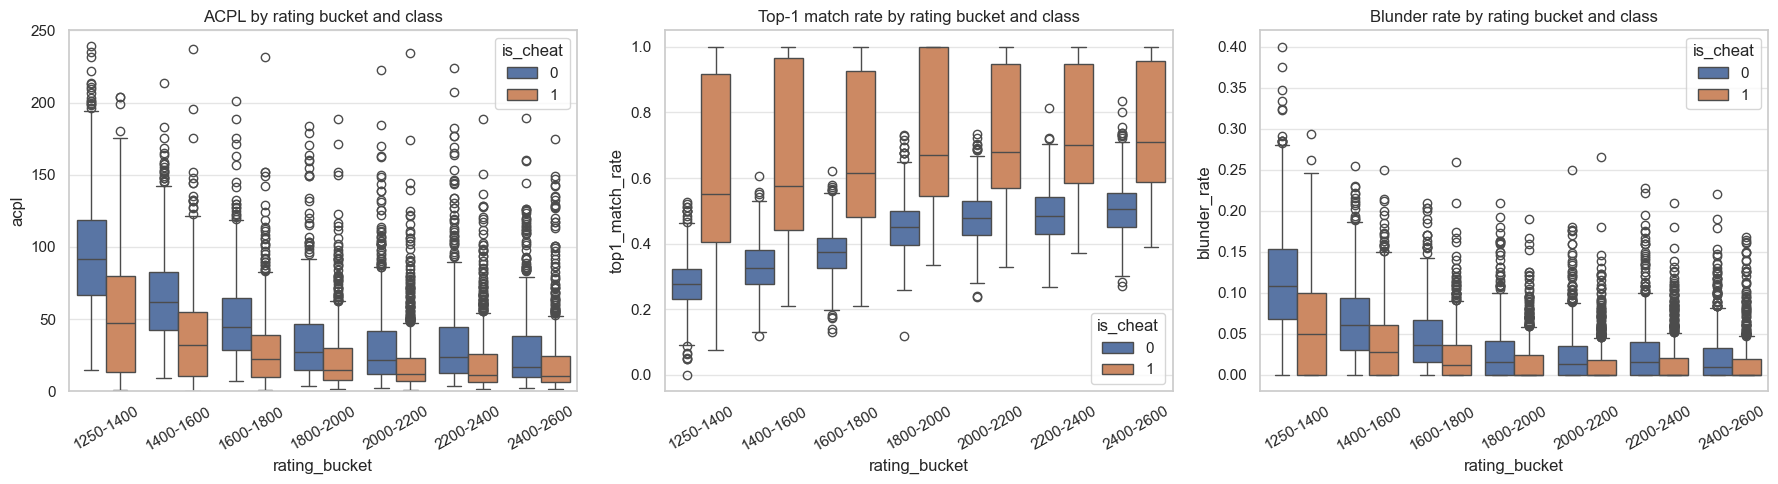

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df, x="rating_bucket", y="acpl", hue="is_cheat",
    order=sorted(df["rating_bucket"].unique()), ax=axes[0]
)
axes[0].set_title("ACPL by rating bucket and class")
axes[0].set_ylim(0, 250)
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=df, x="rating_bucket", y="top1_match_rate", hue="is_cheat",
    order=sorted(df["rating_bucket"].unique()), ax=axes[1]
)
axes[1].set_title("Top-1 match rate by rating bucket and class")
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=df, x="rating_bucket", y="blunder_rate", hue="is_cheat",
    order=sorted(df["rating_bucket"].unique()), ax=axes[2]
)
axes[2].set_title("Blunder rate by rating bucket and class")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("results/eda_class_separation.png", dpi=120, bbox_inches="tight")
plt.show()

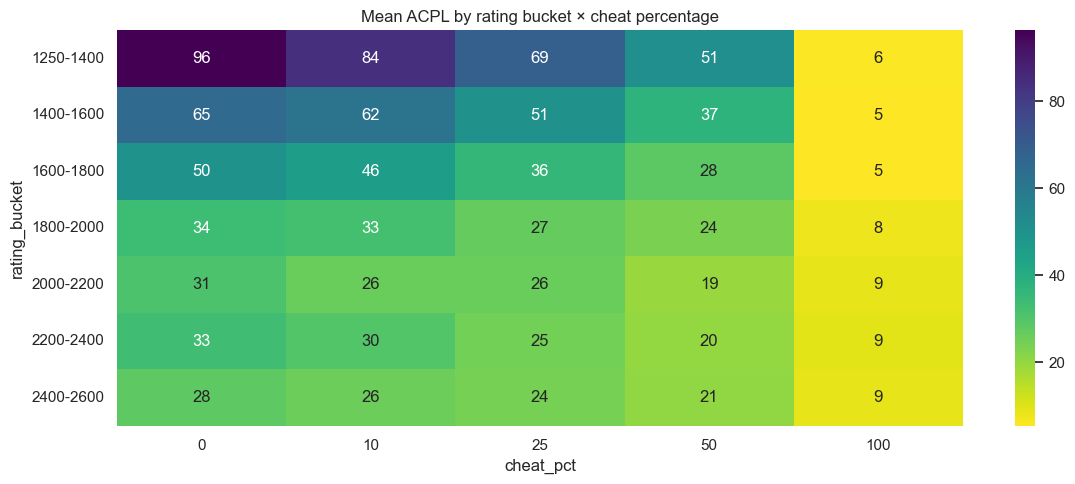

In [41]:
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df.groupby(["rating_bucket", "cheat_pct"])["acpl"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis_r", ax=ax)
ax.set_title("Mean ACPL by rating bucket × cheat percentage")
plt.tight_layout()
plt.savefig("results/eda_acpl_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

The heatmap shows the core signal: ACPL drops sharply along the cheat_pct axis within each rating bucket. At 100% cheat, ACPL collapses to single digits regardless of the underlying skill — this is the trivial case the classifier should ace. The interesting question is how well it handles 10% and 25% cheat, where the signal is much weaker.

## 5. Feature engineering: rating-aware z-scores

Raw features like ACPL are not directly comparable across rating buckets — an ACPL of 30 is brilliant for a 1300 player but expected for a 2500 player. To give linear models access to this context, we compute z-scores: for each numeric feature, subtract the mean and divide by the std of **honest games at the same rating bucket**.

**Crucial**: these statistics are computed using *training honest games only*, then applied to both train and test. Computing them on the full dataset would leak the test set's distribution into the features.

In [42]:
BASE_FEATURES = [
    "estimated_rating", "n_moves", "game_ended_naturally",
    "acpl", "acpl_opening", "acpl_middlegame", "acpl_endgame",
    "top1_match_rate", "top3_match_rate",
    "cp_loss_std", "cp_loss_median",
    "only_move_match_rate", "blunder_rate", "mistake_rate",
]
ZSCORE_SOURCE = [
    "acpl", "acpl_middlegame", "top1_match_rate", "top3_match_rate",
    "cp_loss_std", "only_move_match_rate", "blunder_rate", "mistake_rate",
]


def compute_bucket_stats(df_train_honest):
    return df_train_honest.groupby("rating_bucket")[ZSCORE_SOURCE].agg(["mean", "std"])


def apply_zscores(df_any, stats):
    out = df_any.copy()
    for col in ZSCORE_SOURCE:
        means = df_any["rating_bucket"].map(stats[col]["mean"])
        stds = df_any["rating_bucket"].map(stats[col]["std"]).replace(0, 1)
        out[f"{col}_zscore"] = (df_any[col] - means) / stds
    return out


ZSCORE_FEATURES = [f"{c}_zscore" for c in ZSCORE_SOURCE]
ALL_FEATURES = BASE_FEATURES + ZSCORE_FEATURES
TARGET = "is_cheat"
print(f"Total features: {len(ALL_FEATURES)}")

Total features: 22


## 6. Train/test split

Stratified by `is_cheat` to preserve the 50/50 class balance in both sets. 80/20 split.

In [43]:
df_train, df_test = train_test_split(
    df, test_size=0.20, stratify=df[TARGET], random_state=RANDOM_STATE
)

stats = compute_bucket_stats(df_train[df_train[TARGET] == 0])
df_train = apply_zscores(df_train, stats)
df_test = apply_zscores(df_test, stats)

X_train = df_train[ALL_FEATURES].values
y_train = df_train[TARGET].values
X_test = df_test[ALL_FEATURES].values
y_test = df_test[TARGET].values

print(f"Train: {len(df_train)}  (honest={sum(y_train==0)}, cheat={sum(y_train==1)})")
print(f"Test:  {len(df_test)}  (honest={sum(y_test==0)}, cheat={sum(y_test==1)})")

Train: 8960  (honest=4480, cheat=4480)
Test:  2240  (honest=1120, cheat=1120)


## 7. Multi-model comparison (5-fold CV on training set)

Before committing to a single model, we benchmark five classical families with cross-validation on the training set. All models use default-ish hyperparameters — we are looking at relative performance, not absolute tuning.

In [31]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.08,
        n_jobs=-1, eval_metric="logloss", random_state=RANDOM_STATE,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    results.append({
        "model": name,
        "roc_auc_mean": auc.mean(), "roc_auc_std": auc.std(),
        "f1_mean": f1.mean(), "f1_std": f1.std(),
    })
results_df = pd.DataFrame(results).sort_values("roc_auc_mean", ascending=False)
results_df.round(4)

,model,roc_auc_mean,roc_auc_std,f1_mean,f1_std
3,GradientBoosting,0.9112,0.0072,0.8270,0.0117
0,LogReg,0.9107,0.0055,0.8280,0.0113
2,RandomForest,0.9060,0.0059,0.8236,0.0090
1,SVM (RBF),0.9057,0.0053,0.8206,0.0124
4,XGBoost,0.9033,0.0080,0.8172,0.0118


## 8. Final model: Gradient Boosting

The cross-validation table above shows all five model families landing within ~0.008 AUC of each other — essentially a tie within noise (the spread across models is smaller than the per-fold standard deviation). We pick `GradientBoostingClassifier` (sklearn) as the final model because it edged out the others by the narrowest margin, while noting that the more interesting observation is that a simple Logistic Regression is basically competitive. This suggests that the rating-aware z-score features are doing the heavy lifting, not the model class.

We train on the full training set and evaluate on the held-out test set.

In [32]:
final_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test F1:       {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["honest", "cheat"]))

Test accuracy: 0.8339
Test F1:       0.8220
Test ROC-AUC:  0.9069

              precision    recall  f1-score   support

      honest       0.79      0.90      0.84      1120
       cheat       0.89      0.77      0.82      1120

    accuracy                           0.83      2240
   macro avg       0.84      0.83      0.83      2240
weighted avg       0.84      0.83      0.83      2240



## 9. ROC analysis

Global ROC tells us overall discriminative power. The more revealing analysis is **ROC stratified by cheat_pct**: how does performance degrade as cheating becomes more subtle? A useful model handles 100% cheat trivially and degrades gracefully toward 10%.

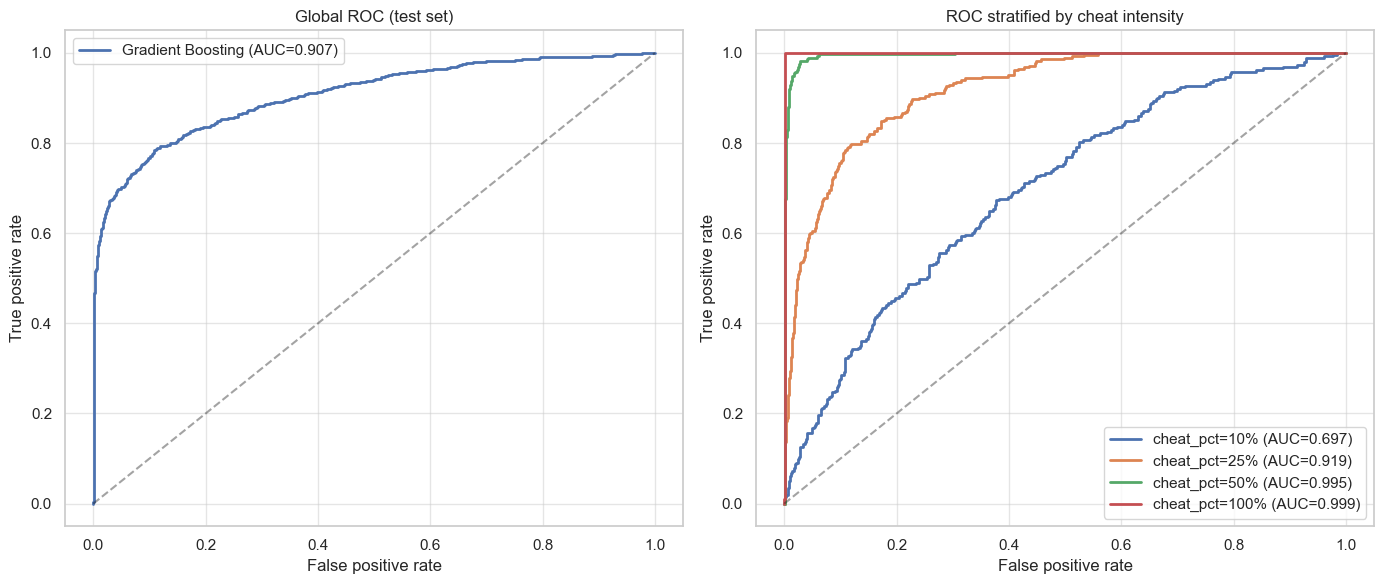

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"Gradient Boosting (AUC={auc:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Global ROC (test set)")
axes[0].legend()

honest_proba = y_proba[y_test == 0]
for pct in sorted(df_test[df_test.is_cheat == 1]["cheat_pct"].unique()):
    mask_cheat = (df_test.is_cheat == 1) & (df_test.cheat_pct == pct)
    y_sub = np.concatenate([np.zeros(len(honest_proba)), np.ones(mask_cheat.sum())])
    p_sub = np.concatenate([honest_proba, y_proba[mask_cheat.values]])
    fpr_s, tpr_s, _ = roc_curve(y_sub, p_sub)
    auc_s = roc_auc_score(y_sub, p_sub)
    axes[1].plot(fpr_s, tpr_s, label=f"cheat_pct={pct}% (AUC={auc_s:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC stratified by cheat intensity")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/roc_global_and_stratified.png", dpi=120, bbox_inches="tight")
plt.show()

The stratified plot is the central result of the work. We expect AUC near 1.0 at 100% cheat (trivial), and degradation toward 0.6-0.8 at 10% cheat (genuinely difficult — only a handful of moves were replaced). This degradation curve is the honest characterization of the model's capability.

## 10. Confusion matrix and feature importance

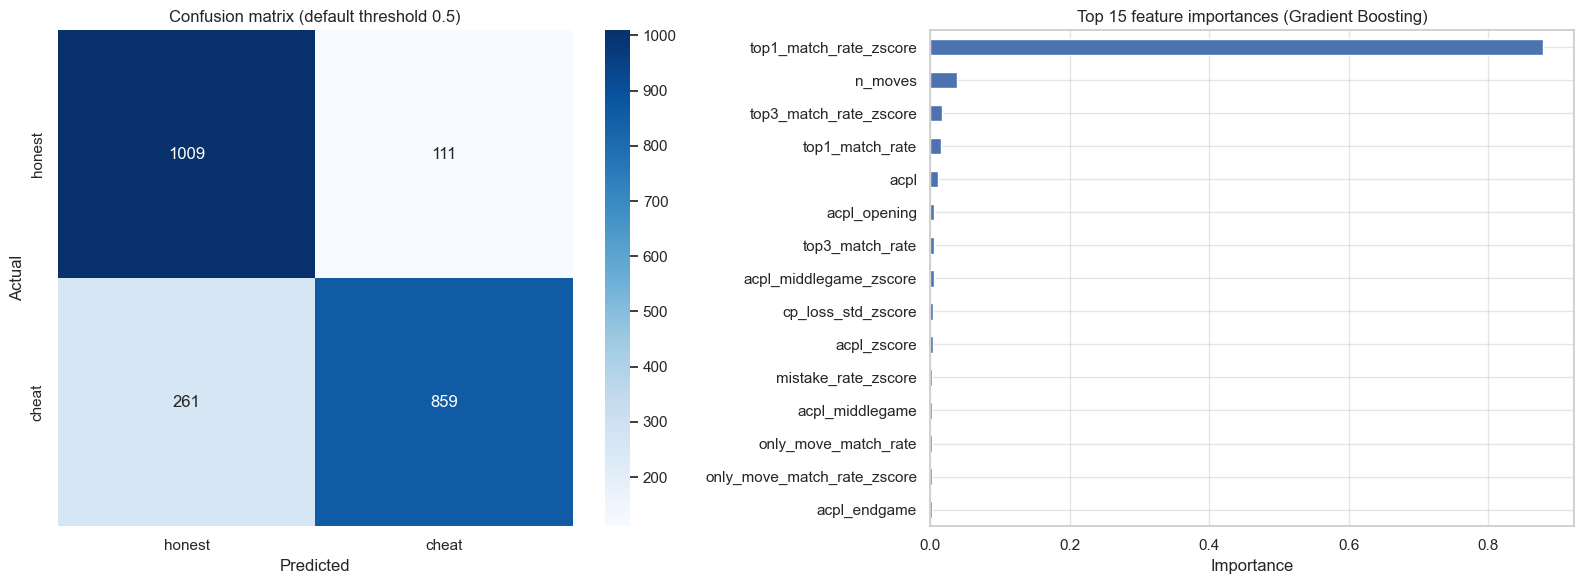

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["honest", "cheat"], yticklabels=["honest", "cheat"],
    ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion matrix (default threshold 0.5)")

importance = pd.Series(final_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
importance.tail(15).plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 15 feature importances (Gradient Boosting)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("results/confusion_and_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Per-bucket evaluation

Is performance uniform across rating buckets, or worse for some?

In [35]:
per_bucket = []
for bucket in sorted(df_test["rating_bucket"].unique()):
    mask = df_test["rating_bucket"] == bucket
    if mask.sum() == 0:
        continue
    auc_b = roc_auc_score(y_test[mask.values], y_proba[mask.values])
    acc_b = accuracy_score(y_test[mask.values], y_pred[mask.values])
    per_bucket.append({"rating_bucket": bucket, "n": mask.sum(), "roc_auc": auc_b, "accuracy": acc_b})
pd.DataFrame(per_bucket).round(4)

,rating_bucket,n,roc_auc,accuracy
0,1250-1400,292,0.9123,0.8425
1,1400-1600,311,0.8982,0.8296
2,1600-1800,321,0.9288,0.8505
3,1800-2000,332,0.8998,0.8313
4,2000-2200,329,0.8886,0.8055
5,2200-2400,315,0.9129,0.8540
6,2400-2600,340,0.9100,0.8265


## 12. Limitations and honest framing

The model achieves strong performance on this synthetic task, but several limitations bound its applicability:

**1. Domain shift to humans.** The classifier learned to distinguish weak-Stockfish play from weak-Stockfish-with-strong-injections. Weak engines blunder in characteristic ways (short-horizon tactical misses) that differ from how humans blunder (positional misconceptions, time pressure, miscalculation under fatigue). A model trained here would likely over-flag noisy human play and under-flag stylistically-consistent human cheating.

**2. Single-engine training.** All cheat moves come from Stockfish. A cheater using a different engine (Leela, Komodo) would produce slightly different move distributions, and our model would have reduced sensitivity. A robust real-world detector would train on multiple engines.

**3. Per-game prediction granularity.** We classify whole games. A cheater who cheats in one critical position out of a long honest game would likely escape — features get averaged out. Per-move detection is a harder, separate problem.

**4. The rating-Elo mapping is approximate.** Stockfish Skill Level values map to Elo only roughly; in a real deployment the player's actual rating would be available.

**5. The 10% cheat case is genuinely hard.** With only ~3-5 replaced moves in a typical game, the statistical signal is thin. The stratified ROC quantifies this — that degradation curve is, in our view, the most honest representation of what the model actually does.

**Despite these limitations**, the experimental design demonstrates that classical tabular features (ACPL, top-K match rate, only-move detection) carry substantial signal for engine-assistance detection in a controlled setting, and that gradient-boosted trees can exploit interactions between rating and quality-of-play features effectively. Extending to a human-cheating-detection deployment would require labeled human data — which is precisely the gap this synthetic approach was built to acknowledge rather than paper over.